# Определитель 2D = ориентированная площадь параллелограмма

Два вектора **a** и **b** на плоскости задают параллелограмм.  
Определитель det(a, b) = a₁b₂ − a₂b₁ — это его **ориентированная площадь**:  
- **> 0** если от a к b — против часовой стрелки  
- **< 0** если по часовой  
- **= 0** если векторы коллинеарны (параллелограмм вырожден)

In [49]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch

def det2(a, b):
    return a[0]*b[1] - a[1]*b[0]

def draw_det_parallelogram(ax, a, b, title=None):
    O = np.array([0.0, 0.0])
    verts = np.array([O, a, a + b, b])

    d = det2(a, b)
    color = '#4a90d9' if d > 0 else '#d94a4a' if d < 0 else '#999999'
    sign_label = '> 0 (против ч.с.)' if d > 0 else '< 0 (по ч.с.)' if d < 0 else '= 0 (вырожден)'

    ax.add_patch(Polygon(verts, closed=True, facecolor=color, alpha=0.3,
                         edgecolor=color, linewidth=2))

    ax.annotate('', xy=a, xytext=O,
                arrowprops=dict(arrowstyle='->', color='#1a1a1a', lw=2.5))
    ax.annotate('', xy=b, xytext=O,
                arrowprops=dict(arrowstyle='->', color='#1a1a1a', lw=2.5))

    ax.text(a[0]/2 - 0.3, a[1]/2 + 0.2, r'$\mathbf{a}$', fontsize=15, fontweight='bold', color='#0a3d6b')
    ax.text(b[0]/2 + 0.15, b[1]/2 + 0.2, r'$\mathbf{b}$', fontsize=15, fontweight='bold', color='#6b0a0a')

    ax.plot(0, 0, 'ko', ms=5)
    ax.text(-0.35, -0.35, '$O$', fontsize=13)

    all_pts = verts
    pad = 0.8
    ax.set_xlim(all_pts[:,0].min() - pad, all_pts[:,0].max() + pad)
    ax.set_ylim(all_pts[:,1].min() - pad, all_pts[:,1].max() + pad)
    ax.set_aspect('equal')
    ax.axhline(0, color='#ccc', lw=0.8, zorder=0)
    ax.axvline(0, color='#ccc', lw=0.8, zorder=0)
    ax.grid(True, alpha=0.2)

    area_text = f'det(a, b) = {d:.1f}  ({sign_label})'
    ax.set_title(title or '', fontsize=14, pad=10)
    ax.text(0.5, -0.08, area_text, transform=ax.transAxes, ha='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffacd', edgecolor='#888'))

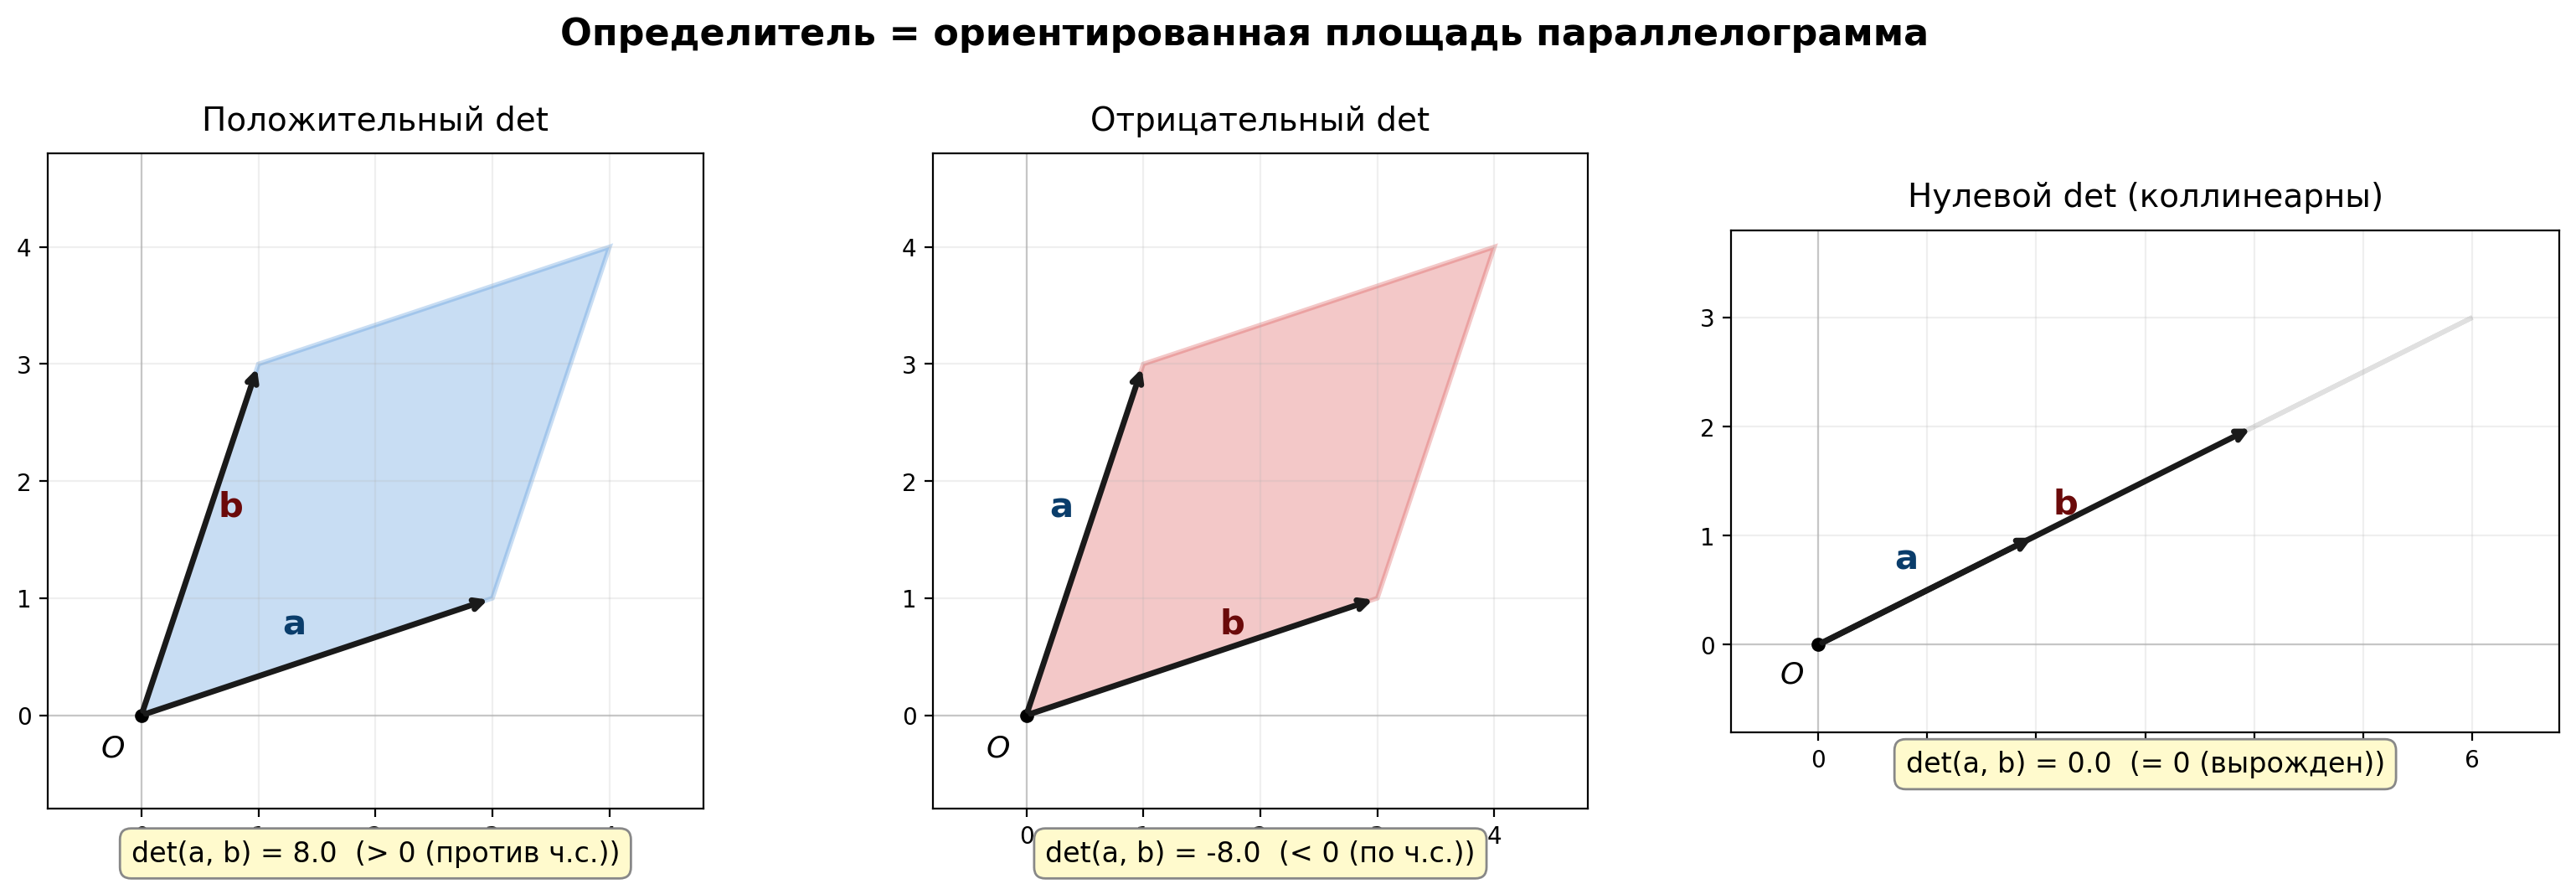

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Случай 1: положительный определитель (от a к b — против часовой)
a1 = np.array([3.0, 1.0])
b1 = np.array([1.0, 3.0])
draw_det_parallelogram(axes[0], a1, b1, 'Положительный det')

# Случай 2: отрицательный определитель (от a к b — по часовой)
a2 = np.array([1.0, 3.0])
b2 = np.array([3.0, 1.0])
draw_det_parallelogram(axes[1], a2, b2, 'Отрицательный det')

# Случай 3: нулевой определитель (коллинеарны)
a3 = np.array([2.0, 1.0])
b3 = np.array([4.0, 2.0])
draw_det_parallelogram(axes[2], a3, b3, 'Нулевой det (коллинеарны)')

plt.suptitle('Определитель = ориентированная площадь параллелограмма',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Что видно на рисунке

- **Слева:** a = (3,1), b = (1,3). Поворот от a к b — против часовой стрелки → det > 0.
- **В центре:** те же векторы поменяны местами → det меняет знак (**антисимметричность**).
- **Справа:** b = 2a, векторы коллинеарны → параллелограмм схлопнулся в отрезок, площадь = 0.

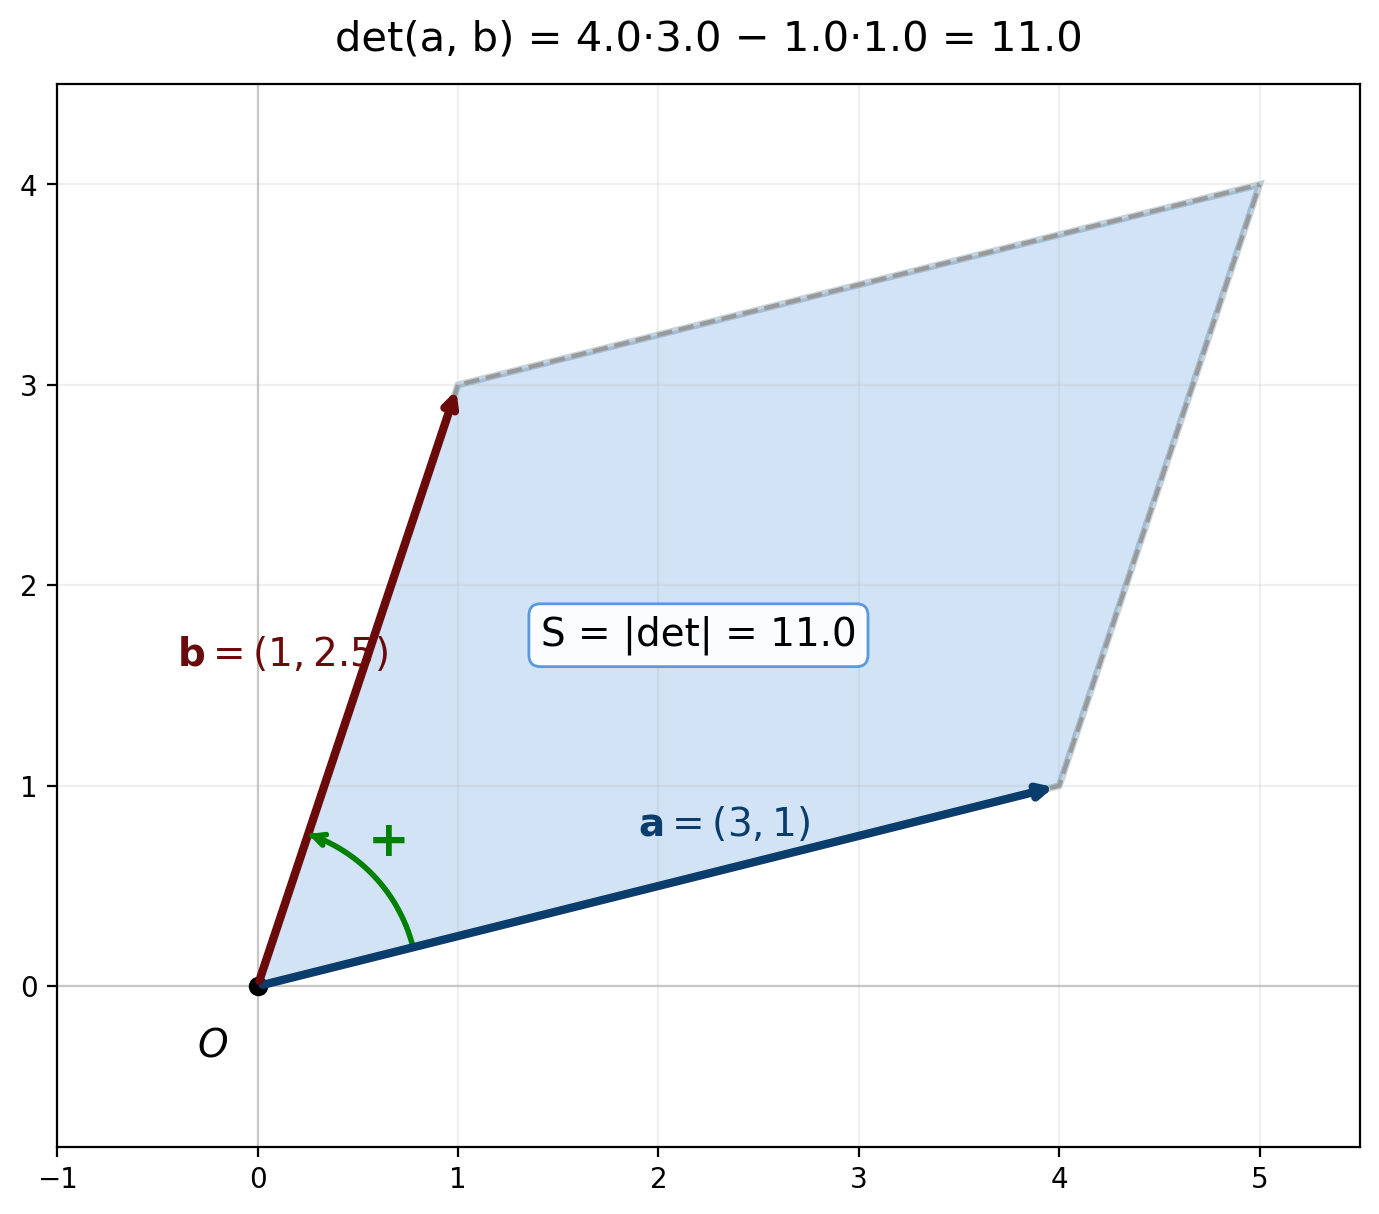

In [51]:
fig, ax = plt.subplots(figsize=(7, 7))

a = np.array([4.0, 1.0])
b = np.array([1.0, 3.0])
O = np.array([0.0, 0.0])

verts = np.array([O, a, a + b, b])
ax.add_patch(Polygon(verts, closed=True, facecolor='#4a90d9', alpha=0.25,
                     edgecolor='#1a5275', linewidth=2.5))

ax.annotate('', xy=a, xytext=O, arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=3))
ax.annotate('', xy=b, xytext=O, arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=3))

ax.plot([0, b[0], a[0]+b[0]], [0, b[1], a[1]+b[1]], '--', color='#999', lw=1.5)
ax.plot([0, a[0], a[0]+b[0]], [0, a[1], a[1]+b[1]], '--', color='#999', lw=1.5)

ax.text(a[0]/2 - 0.1, a[1]/2 + 0.25, r'$\mathbf{a} = (3, 1)$', fontsize=14, color='#0a3d6b', fontweight='bold')
ax.text(b[0]/2 - 0.9, b[1]/2 + 0.1, r'$\mathbf{b} = (1, 2.5)$', fontsize=14, color='#6b0a0a', fontweight='bold')

d = det2(a, b)
cx, cy = (a[0]+b[0])/2, (a[1]+b[1])/2
ax.text(cx - 0.3, cy - 0.3, f'S = |det| = {abs(d):.1f}', fontsize=14,
        ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#4a90d9'))

# Дуга ориентации
angle_a = np.degrees(np.arctan2(a[1], a[0]))
angle_b = np.degrees(np.arctan2(b[1], b[0]))
arc_angles = np.linspace(np.radians(angle_a), np.radians(angle_b), 30)
r = 0.8
ax.plot(r*np.cos(arc_angles), r*np.sin(arc_angles), color='green', lw=2)
ax.annotate('', xy=(r*np.cos(arc_angles[-1]), r*np.sin(arc_angles[-1])),
            xytext=(r*np.cos(arc_angles[-2]), r*np.sin(arc_angles[-2])),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(0.55, 0.65, '+', fontsize=18, color='green', fontweight='bold')

ax.plot(0, 0, 'ko', ms=6)
ax.text(-0.3, -0.35, '$O$', fontsize=14)
ax.set_xlim(-1, 5.5)
ax.set_ylim(-0.8, 4.5)
ax.set_aspect('equal')
ax.axhline(0, color='#ccc', lw=0.8, zorder=0)
ax.axvline(0, color='#ccc', lw=0.8, zorder=0)
ax.grid(True, alpha=0.2)
ax.set_title(f'det(a, b) = {a[0]}·{b[1]} − {a[1]}·{b[0]} = {d:.1f}',
             fontsize=15, pad=12)
plt.tight_layout()
plt.show()

## Откуда берётся формула a₁b₂ − a₂b₁?

Обводим параллелограмм **большим прямоугольником** со сторонами (a₁+b₁) и (a₂+b₂).
Между ним и параллелограммом остаётся 6 кусочков — **попарно одинаковых**:

| Кусок (×2) | Площадь одного |
|---|---|
| Треугольник «вдоль a» | a₁·a₂ / 2 |
| Треугольник «вдоль b» | b₁·b₂ / 2 |
| Прямоугольник в углу | **a₂·b₁** |

Площадь параллелограмма = большой прямоугольник − все 6 кусков:

(a₁+b₁)(a₂+b₂) − 2·(a₁a₂/2) − 2·(b₁b₂/2) − 2·(a₂b₁)
= a₁a₂ + **a₁b₂** + a₂b₁ + b₁b₂ − a₁a₂ − b₁b₂ − 2·a₂b₁
= **a₁b₂ − a₂b₁**

Никакой магии — просто арифметика прямоугольника и треугольников.

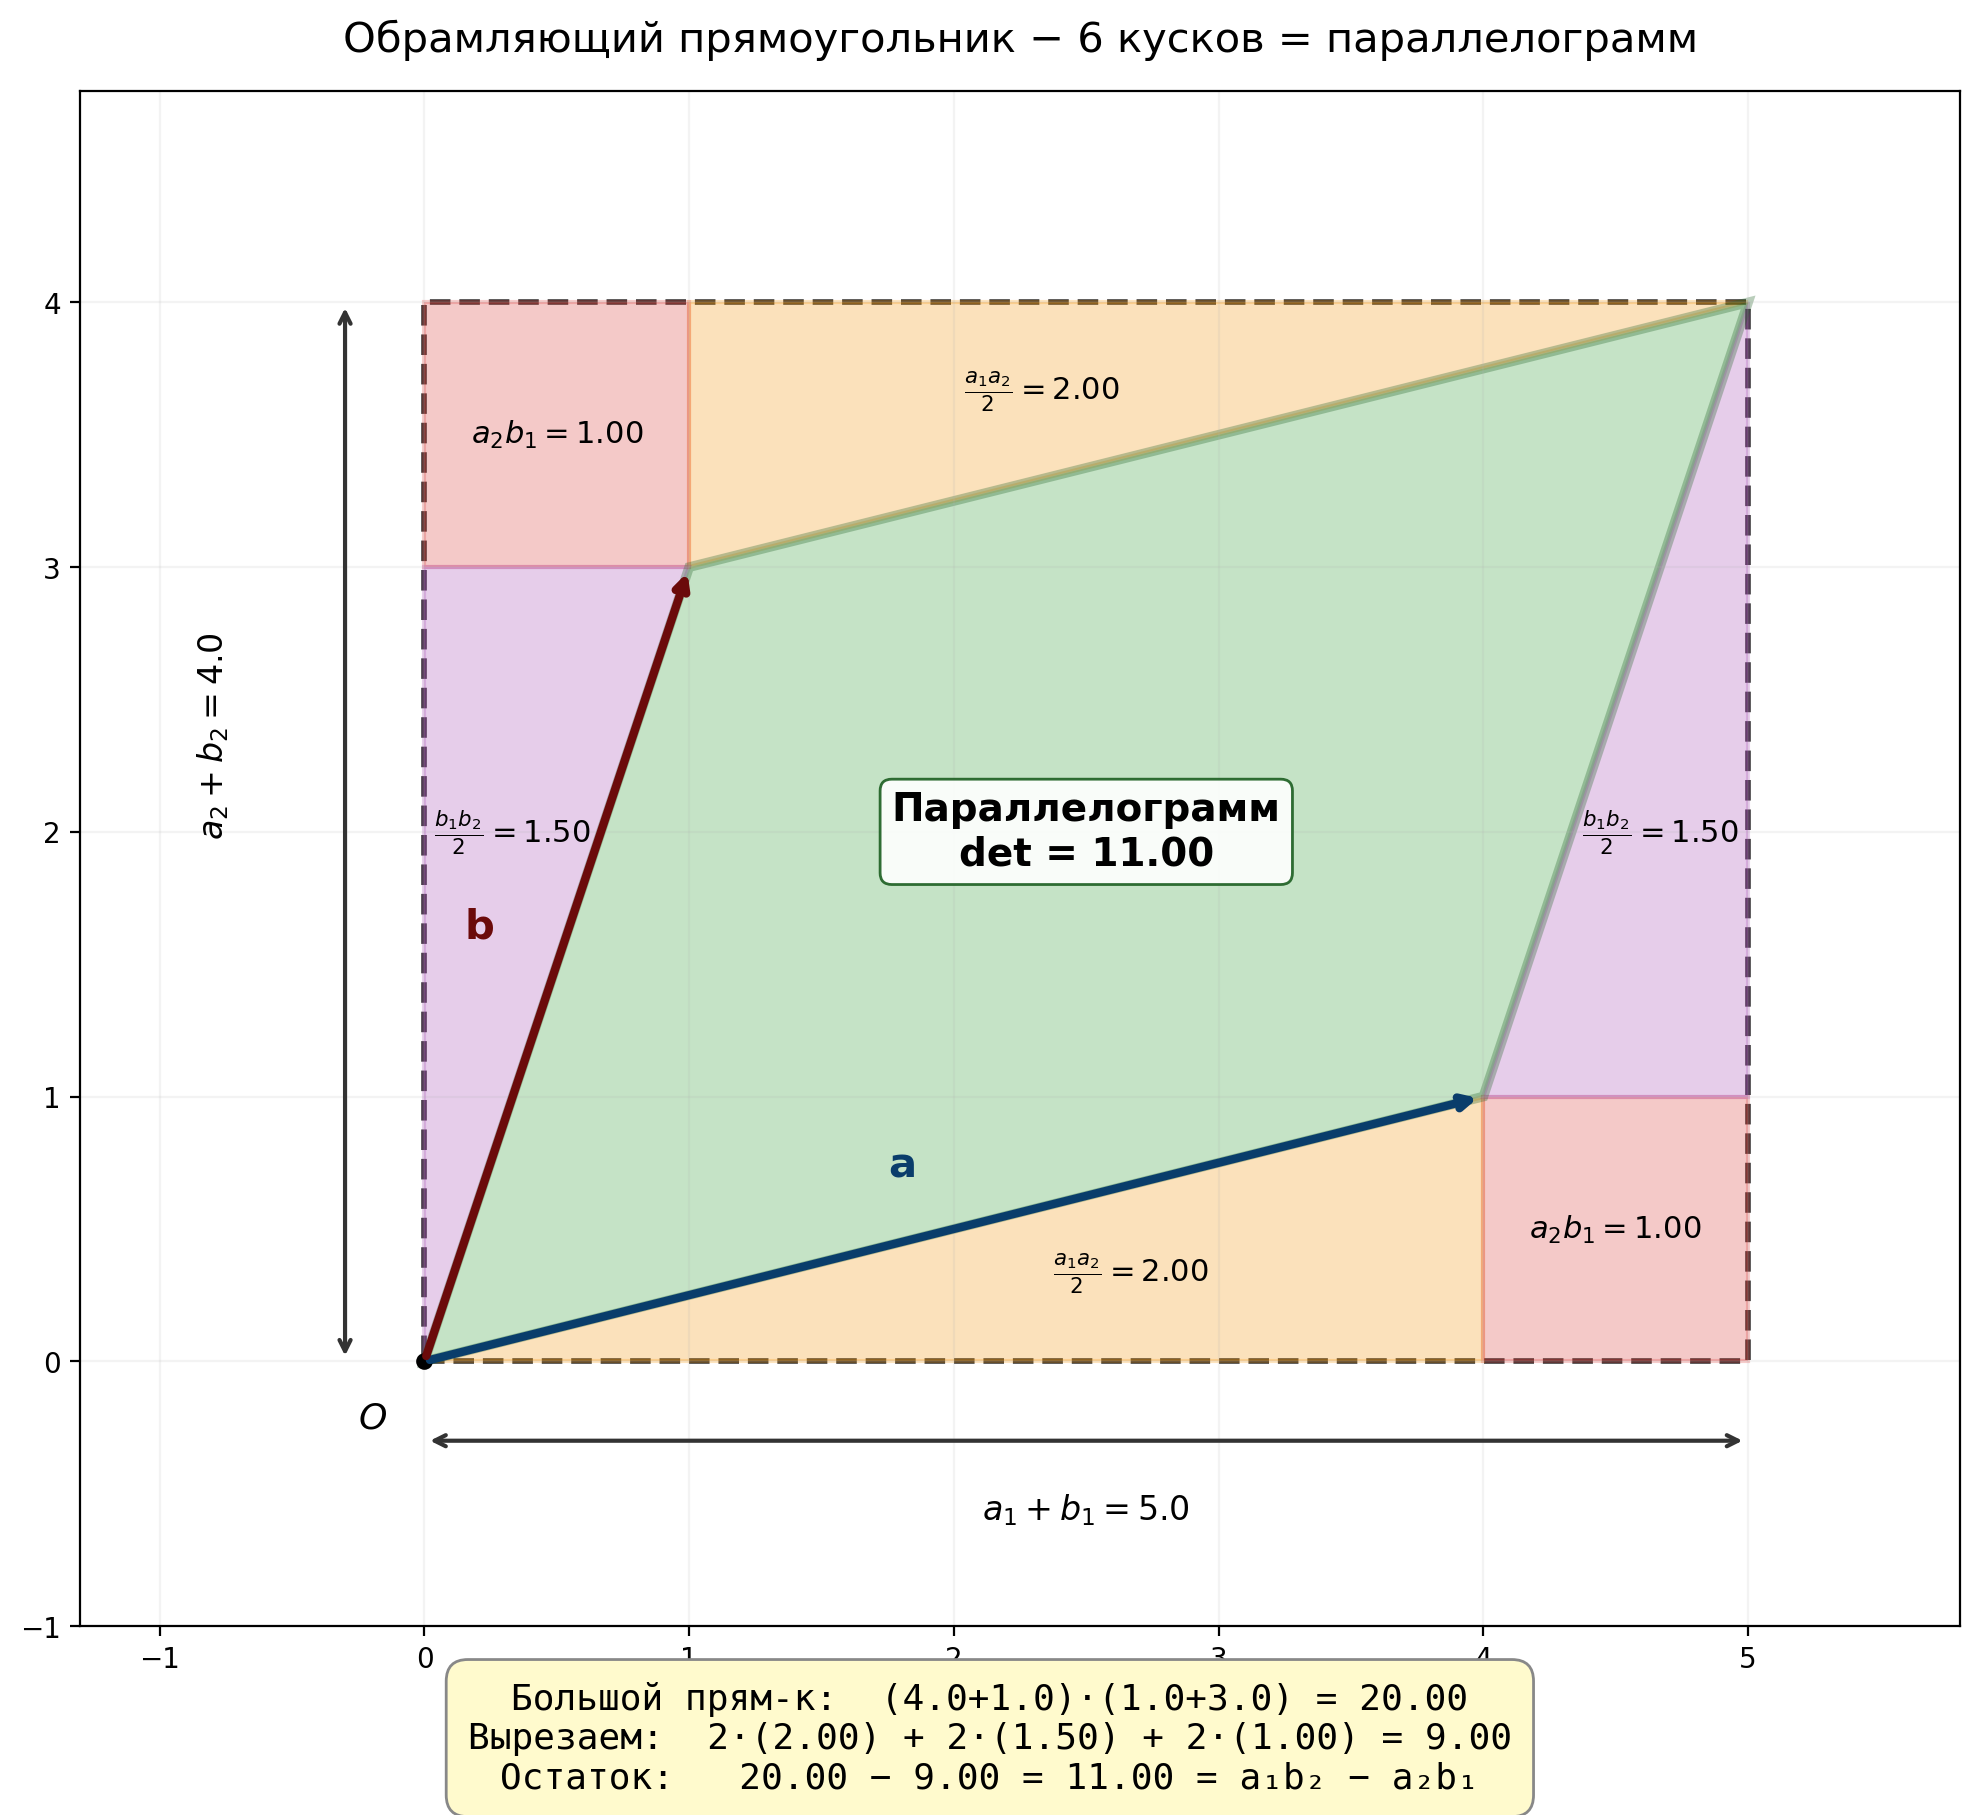

In [52]:
a = np.array([4.0, 1.0])
b = np.array([1.0, 3.0])

a1, a2 = a
b1, b2 = b
W = a1 + b1
H = a2 + b2

# 6 кусков, которые вырезаем из обрамляющего прямоугольника
tri_a1 = np.array([[0, 0], [a1, 0], [a1, a2]])
rect_br = np.array([[a1, 0], [W, 0], [W, a2], [a1, a2]])
tri_b1  = np.array([[a1, a2], [W, a2], [W, H]])

tri_a2 = np.array([[b1, b2], [b1, H], [W, H]])
rect_tl = np.array([[0, b2], [b1, b2], [b1, H], [0, H]])
tri_b2  = np.array([[0, 0], [0, b2], [b1, b2]])

para = np.array([[0, 0], [a1, a2], [W, H], [b1, b2]])

pieces = [
    (tri_a1,  '#ff9800', f'$\\frac{{a_1 a_2}}{{2}}={a1*a2/2:.2f}$',  'Т₁'),
    (rect_br, '#e53935', f'$a_2 b_1={a2*b1:.2f}$',                   'П'),
    (tri_b1,  '#ab47bc', f'$\\frac{{b_1 b_2}}{{2}}={b1*b2/2:.2f}$',  'Т₂'),
    (tri_a2,  '#ff9800', f'$\\frac{{a_1 a_2}}{{2}}={a1*a2/2:.2f}$',  'Т₁'),
    (rect_tl, '#e53935', f'$a_2 b_1={a2*b1:.2f}$',                   'П'),
    (tri_b2,  '#ab47bc', f'$\\frac{{b_1 b_2}}{{2}}={b1*b2/2:.2f}$',  'Т₂'),
]

fig, ax = plt.subplots(figsize=(10, 9))

bounding = plt.Rectangle((0, 0), W, H, facecolor='#fafafa', edgecolor='#333',
                          linewidth=2, linestyle='--')
ax.add_patch(bounding)

for verts, color, label, short in pieces:
    cx, cy = verts.mean(axis=0)
    ax.add_patch(Polygon(verts, closed=True, facecolor=color, alpha=0.25,
                         edgecolor=color, linewidth=1.5))
    ax.text(cx, cy, label, ha='center', va='center', fontsize=11, fontweight='bold')

ax.add_patch(Polygon(para, closed=True, facecolor='#4caf50', alpha=0.30,
                     edgecolor='#1b5e20', linewidth=3.5))

pcx, pcy = para.mean(axis=0)
d = a1*b2 - a2*b1
ax.text(pcx, pcy, f'Параллелограмм\ndet = {d:.2f}', ha='center', va='center',
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#1b5e20'))

ax.annotate('', xy=a, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=3))
ax.annotate('', xy=b, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=3))
ax.text(a[0]/2 - 0.25, a[1]/2 + 0.2, r'$\mathbf{a}$', fontsize=15, color='#0a3d6b', fontweight='bold')
ax.text(b[0]/2 - 0.35, b[1]/2 + 0.1, r'$\mathbf{b}$', fontsize=15, color='#6b0a0a', fontweight='bold')

ax.annotate('', xy=(W, -0.3), xytext=(0, -0.3),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.5))
ax.text(W/2, -0.6, f'$a_1+b_1 = {W:.1f}$', ha='center', fontsize=12)

ax.annotate('', xy=(-0.3, H), xytext=(-0.3, 0),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.5))
ax.text(-0.8, H/2, f'$a_2+b_2 = {H:.1f}$', ha='center', fontsize=12, rotation=90)

ax.plot(0, 0, 'ko', ms=5)
ax.text(-0.25, -0.25, '$O$', fontsize=13)

ax.set_xlim(-1.3, W + 0.8)
ax.set_ylim(-1.0, H + 0.8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)

cut = 2*(a1*a2/2) + 2*(b1*b2/2) + 2*(a2*b1)
box_area = W * H

ax.set_title('Обрамляющий прямоугольник − 6 кусков = параллелограмм', fontsize=15, pad=14)

legend_text = (
    f'Большой прям-к:  ({a1}+{b1})·({a2}+{b2}) = {box_area:.2f}\n'
    f'Вырезаем:  2·({a1*a2/2:.2f}) + 2·({b1*b2/2:.2f}) + 2·({a2*b1:.2f}) = {cut:.2f}\n'
    f'Остаток:   {box_area:.2f} − {cut:.2f} = {d:.2f} = a₁b₂ − a₂b₁'
)
fig.text(0.5, -0.02, legend_text, ha='center', fontsize=13,
         family='monospace',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#fffacd', edgecolor='#888'))

plt.tight_layout()
plt.show()

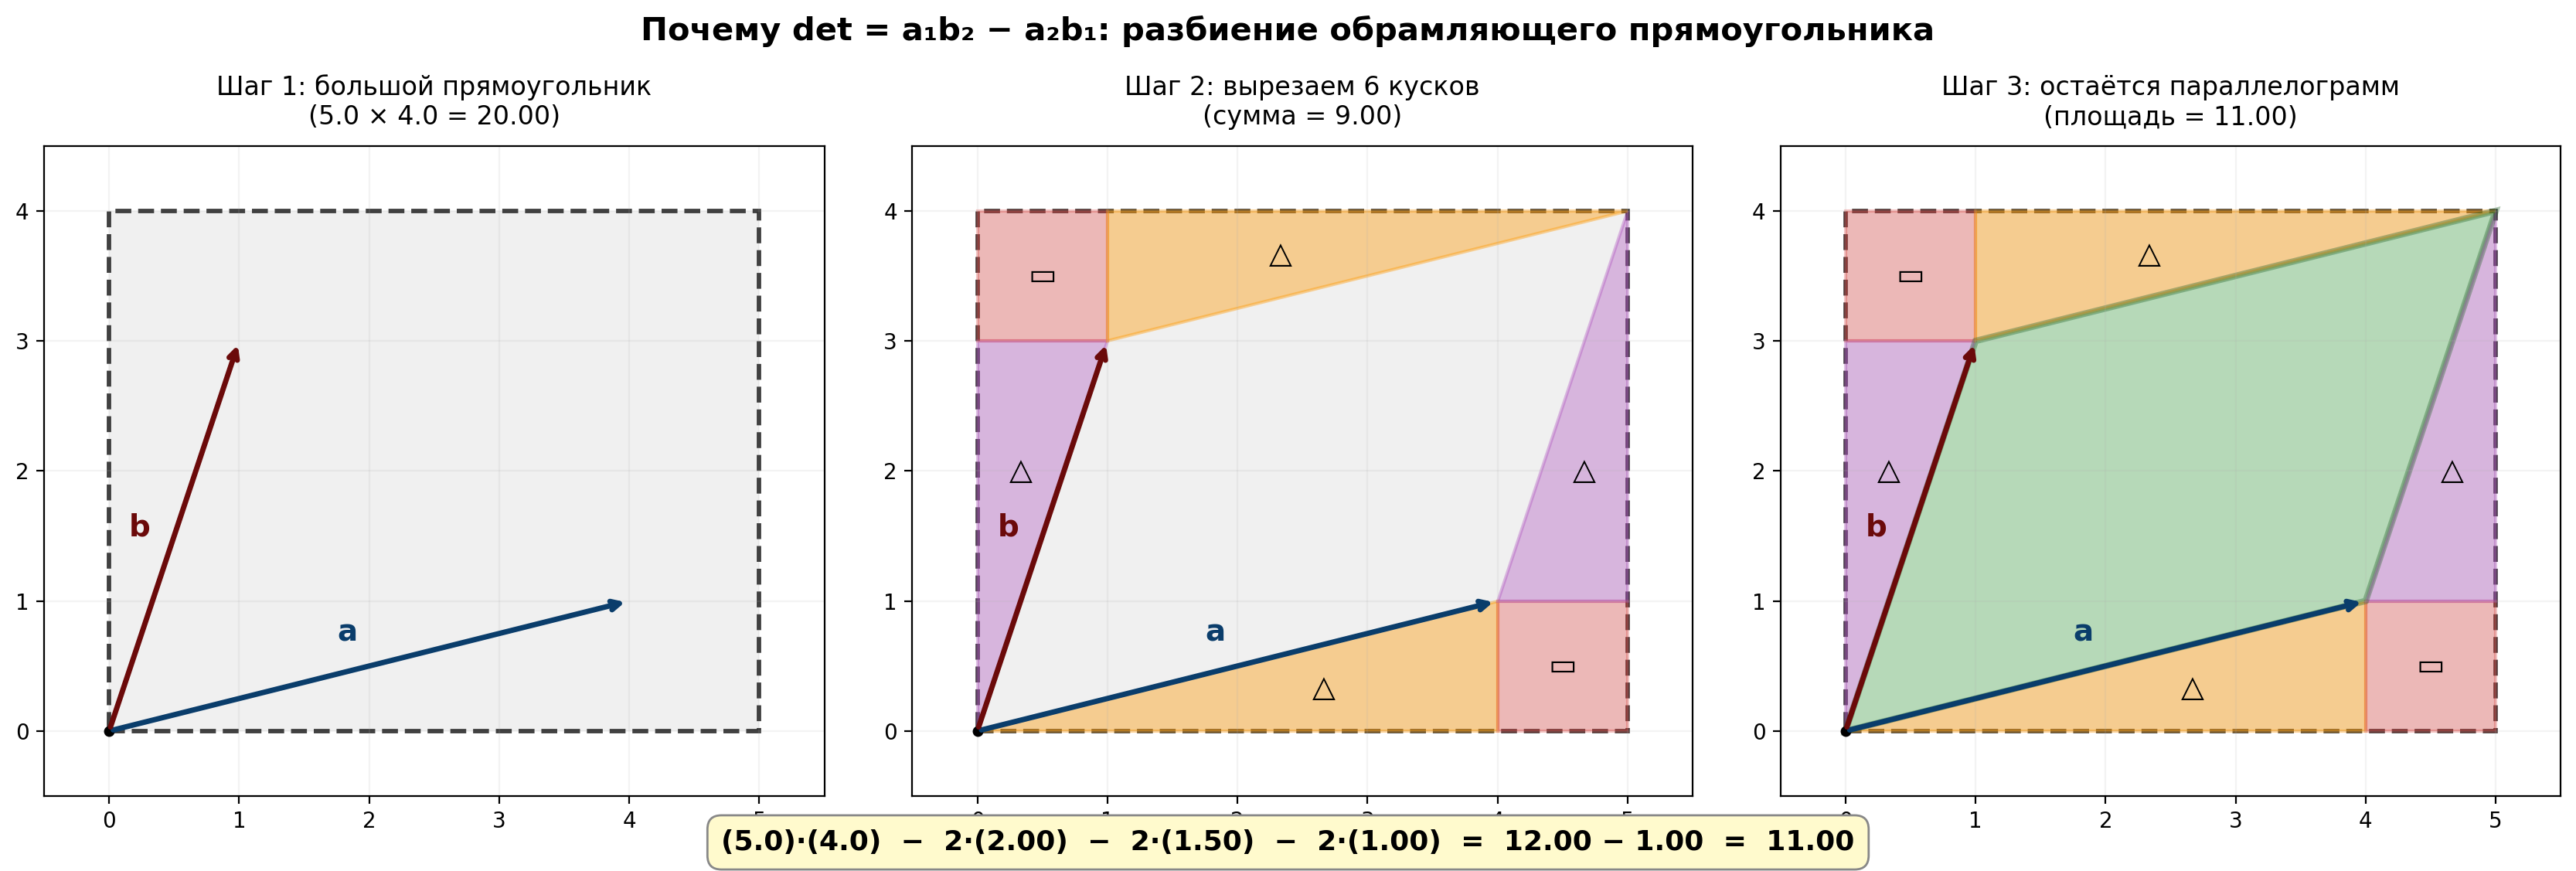

In [53]:
a1, a2 = a
b1, b2 = b
W, H = a1 + b1, a2 + b2

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

para = np.array([[0,0], [a1,a2], [W,H], [b1,b2]])

tri_a_bot  = np.array([[0,0], [a1,0], [a1,a2]])
rect_br    = np.array([[a1,0], [W,0], [W,a2], [a1,a2]])
tri_b_rt   = np.array([[a1,a2], [W,a2], [W,H]])

tri_b_lt   = np.array([[0,0], [0,b2], [b1,b2]])
rect_tl    = np.array([[0,b2], [b1,b2], [b1,H], [0,H]])
tri_a_top  = np.array([[b1,b2], [b1,H], [W,H]])

cutoffs = [
    (tri_a_bot, '#ff9800', 0.4),
    (rect_br,   '#e53935', 0.3),
    (tri_b_rt,  '#ab47bc', 0.35),
    (tri_b_lt,  '#ab47bc', 0.35),
    (rect_tl,   '#e53935', 0.3),
    (tri_a_top, '#ff9800', 0.4),
]

titles = [
    f'Шаг 1: большой прямоугольник\n({W:.1f} × {H:.1f} = {W*H:.2f})',
    f'Шаг 2: вырезаем 6 кусков\n(сумма = {W*H - (a1*b2-a2*b1):.2f})',
    f'Шаг 3: остаётся параллелограмм\n(площадь = {a1*b2-a2*b1:.2f})',
]

for i, ax in enumerate(axes):
    ax.add_patch(plt.Rectangle((0, 0), W, H, facecolor='#f0f0f0', edgecolor='#333',
                                linewidth=2, linestyle='--'))

    if i >= 1:
        for verts, color, alpha in cutoffs:
            ax.add_patch(Polygon(verts, closed=True, facecolor=color,
                                 alpha=alpha, edgecolor=color, linewidth=1.5))
            cx, cy = verts.mean(axis=0)
            n = len(verts)
            label = {3: '△', 4: '▭'}[n]
            ax.text(cx, cy, label, ha='center', va='center', fontsize=14, fontweight='bold')

    if i == 0 or i == 2:
        fc = '#4caf50' if i == 2 else 'none'
        al = 0.35 if i == 2 else 0
        ax.add_patch(Polygon(para, closed=True, facecolor=fc, alpha=al,
                             edgecolor='#1b5e20', linewidth=3))

    ax.annotate('', xy=a, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=2.5))
    ax.annotate('', xy=b, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=2.5))
    ax.text(a[0]/2 - 0.25, a[1]/2 + 0.2, r'$\mathbf{a}$', fontsize=14,
            color='#0a3d6b', fontweight='bold')
    ax.text(b[0]/2 - 0.35, b[1]/2, r'$\mathbf{b}$', fontsize=14,
            color='#6b0a0a', fontweight='bold')

    ax.plot(0, 0, 'ko', ms=4)
    ax.set_xlim(-0.5, W + 0.5)
    ax.set_ylim(-0.5, H + 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    ax.set_title(titles[i], fontsize=12, pad=10)

fig.text(0.5, -0.04,
         f'({W:.1f})·({H:.1f})  −  2·({a1*a2/2:.2f})  −  2·({b1*b2/2:.2f})  −  2·({a2*b1:.2f})'
         f'  =  {a1*b2:.2f} − {a2*b1:.2f}  =  {a1*b2 - a2*b1:.2f}',
         ha='center', fontsize=13, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fffacd', edgecolor='#888'))

plt.suptitle('Почему det = a₁b₂ − a₂b₁: разбиение обрамляющего прямоугольника',
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## Как это читать

1. **Шаг 1:** обводим параллелограмм большим пунктирным прямоугольником (a₁+b₁) × (a₂+b₂).
2. **Шаг 2:** между прямоугольником и параллелограммом ровно 6 кусков — попарно одинаковых:
   - **△ оранжевые** (×2) — треугольники «вдоль a», каждый площадью a₁a₂/2
   - **△ фиолетовые** (×2) — треугольники «вдоль b», каждый площадью b₁b₂/2
   - **▭ красные** (×2) — прямоугольники в противоположных углах, каждый площадью **a₂·b₁**
3. **Шаг 3:** вычитаем все 6 кусков из большого прямоугольника → всё сокращается и остаётся **a₁b₂ − a₂b₁**.

Ключевой момент: произведение a₂·b₁ входит в формулу со знаком **минус** именно потому, что два прямоугольника-«уголка» суммарно дают 2·a₂b₁ и перевешивают слагаемое +a₂b₁ из раскрытия скобок.

## Где «живут» a₁b₂ и a₂b₁ на самой картинке?

Из начала координат O в противоположную вершину параллелограмма A+B можно прийти двумя «лесенками»:

- **Путь 1:** O → A → A+B (сначала вдоль **a**, потом вдоль **b**)
- **Путь 2:** O → B → A+B (сначала вдоль **b**, потом вдоль **a**)

Площадь под каждой лесенкой (до оси x) разбивается на три куска:

| | Треугольник | **Прямоугольник** | Треугольник |
|---|---|---|---|
| Путь 1 (a→b) | a₁a₂/2 | **a₂b₁** | b₁b₂/2 |
| Путь 2 (b→a) | b₁b₂/2 | **a₁b₂** | a₁a₂/2 |

Треугольники **одинаковые** — они сокращаются! Остаётся:

**Путь 2 − Путь 1 = a₁b₂ − a₂b₁ = площадь параллелограмма**

Прямоугольники a₁b₂ и a₂b₁ — это **средние куски** каждой лесенки. Они видны прямо на рисунке.

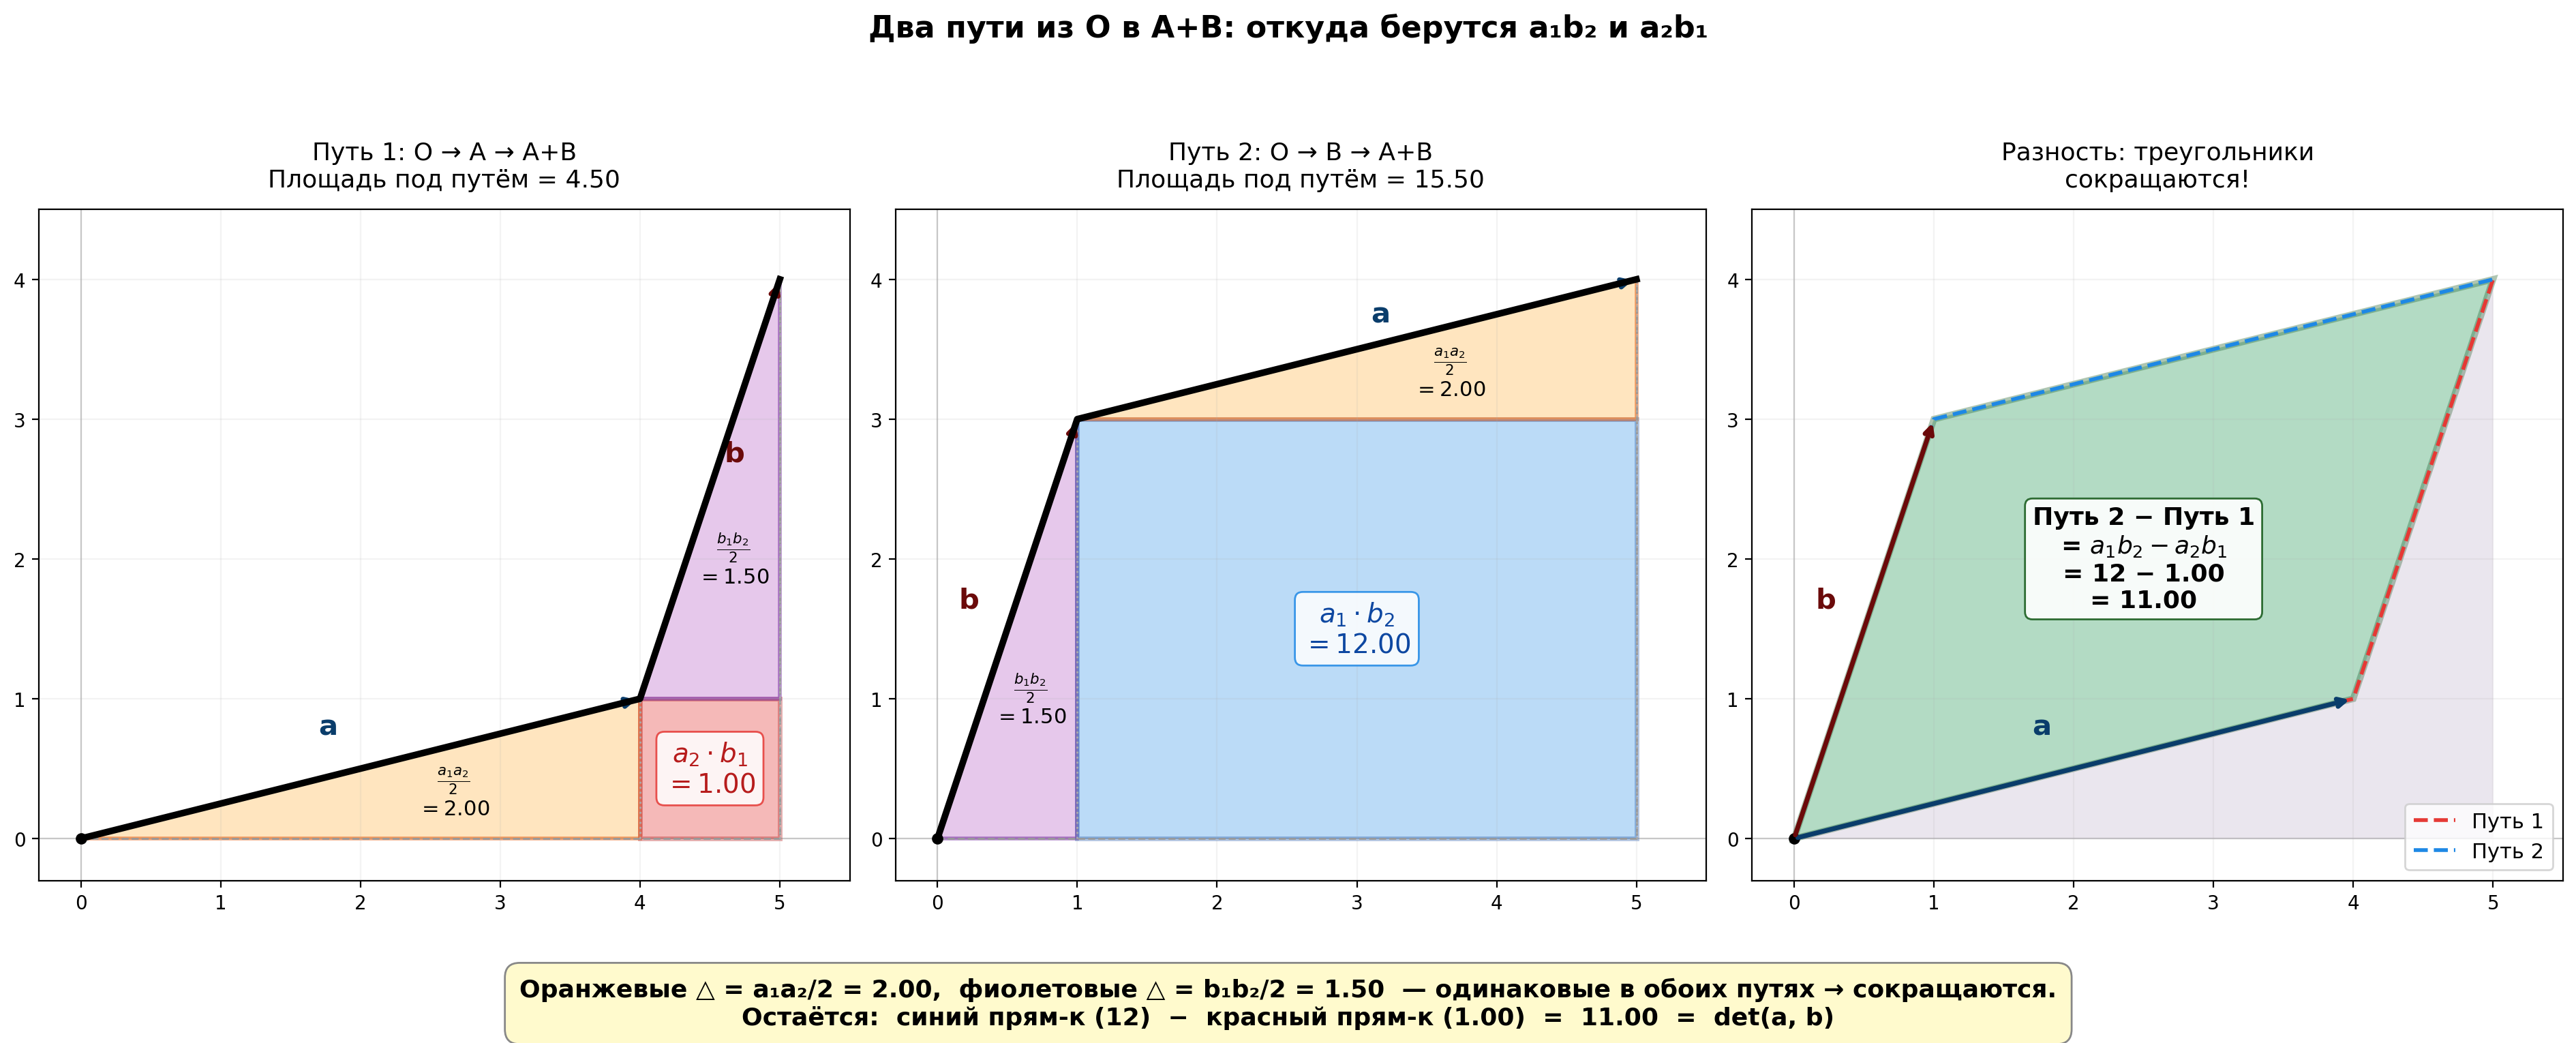

In [ ]:
a = np.array([4.0, 1.0])
b = np.array([1.0, 3.0])
a1, a2 = a
b1, b2 = b
W, H = a1 + b1, a2 + b2

# Путь 1: O → A → A+B (сначала a, потом b)
# Под этим путём три куска:
p1_tri1 = np.array([[0,0], [a1,0], [a1,a2]])              # a₁a₂/2
p1_rect = np.array([[a1,0], [W,0], [W,a2], [a1,a2]])      # a₂·b₁  ← ВОТ ОН
p1_tri2 = np.array([[a1,a2], [W,a2], [W,H]])               # b₁b₂/2

# Путь 2: O → B → A+B (сначала b, потом a)
p2_tri1 = np.array([[0,0], [b1,0], [b1,b2]])              # b₁b₂/2
p2_rect = np.array([[b1,0], [W,0], [W,b2], [b1,b2]])      # a₁·b₂  ← ВОТ ОН
p2_tri2 = np.array([[b1,b2], [W,b2], [W,H]])               # a₁a₂/2

para = np.array([[0,0], [a1,a2], [W,H], [b1,b2]])

fig, axes = plt.subplots(1, 3, figsize=(19, 7))

# ─── Левая: Путь 1 (a → b) ───
ax = axes[0]
ax.add_patch(Polygon(p1_tri1, closed=True, facecolor='#ffcc80', alpha=0.5,
                     edgecolor='#e65100', linewidth=2))
ax.add_patch(Polygon(p1_rect, closed=True, facecolor='#e53935', alpha=0.35,
                     edgecolor='#b71c1c', linewidth=2.5))
ax.add_patch(Polygon(p1_tri2, closed=True, facecolor='#ce93d8', alpha=0.5,
                     edgecolor='#6a1b9a', linewidth=2))

cx1, cy1 = p1_tri1.mean(axis=0)
ax.text(cx1, cy1, f'$\\frac{{a_1 a_2}}{{2}}$\n$={a1*a2/2:.2f}$',
        ha='center', va='center', fontsize=11, fontweight='bold')
cx, cy = p1_rect.mean(axis=0)
ax.text(cx, cy, f'$a_2 \\cdot b_1$\n$= {a2*b1:.2f}$',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#b71c1c',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#e53935'))
cx2, cy2 = p1_tri2.mean(axis=0)
ax.text(cx2, cy2, f'$\\frac{{b_1 b_2}}{{2}}$\n$={b1*b2/2:.2f}$',
        ha='center', va='center', fontsize=11, fontweight='bold')

path1_x = [0, a1, W]
path1_y = [0, a2, H]
ax.plot(path1_x, path1_y, 'k-', lw=3.5, zorder=5)
ax.plot([0, W, W], [0, 0, H], color='#999', lw=1, linestyle='--')
for px, py in zip(path1_x, path1_y):
    ax.plot([px, px], [0, py], ':', color='#aaa', lw=1)

ax.annotate('', xy=a, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=2.5))
ax.annotate('', xy=[W,H], xytext=a, arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=2.5))
ax.text(a1/2-0.3, a2/2+0.25, r'$\mathbf{a}$', fontsize=15, color='#0a3d6b', fontweight='bold')
ax.text(a1+b1/2+0.1, a2+b2/2+0.2, r'$\mathbf{b}$', fontsize=15, color='#6b0a0a', fontweight='bold')

ax.set_title(f'Путь 1: O → A → A+B\nПлощадь под путём = {a1*a2/2 + a2*b1 + b1*b2/2:.2f}',
             fontsize=13, pad=12)

# ─── Центральная: Путь 2 (b → a) ───
ax = axes[1]
ax.add_patch(Polygon(p2_tri1, closed=True, facecolor='#ce93d8', alpha=0.5,
                     edgecolor='#6a1b9a', linewidth=2))
ax.add_patch(Polygon(p2_rect, closed=True, facecolor='#1e88e5', alpha=0.30,
                     edgecolor='#0d47a1', linewidth=2.5))
ax.add_patch(Polygon(p2_tri2, closed=True, facecolor='#ffcc80', alpha=0.5,
                     edgecolor='#e65100', linewidth=2))

cx1, cy1 = p2_tri1.mean(axis=0)
ax.text(cx1, cy1, f'$\\frac{{b_1 b_2}}{{2}}$\n$={b1*b2/2:.2f}$',
        ha='center', va='center', fontsize=11, fontweight='bold')
cx, cy = p2_rect.mean(axis=0)
ax.text(cx, cy, f'$a_1 \\cdot b_2$\n$= {a1*b2:.2f}$',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#0d47a1',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#1e88e5'))
cx2, cy2 = p2_tri2.mean(axis=0)
ax.text(cx2, cy2, f'$\\frac{{a_1 a_2}}{{2}}$\n$={a1*a2/2:.2f}$',
        ha='center', va='center', fontsize=11, fontweight='bold')

path2_x = [0, b1, W]
path2_y = [0, b2, H]
ax.plot(path2_x, path2_y, 'k-', lw=3.5, zorder=5)
ax.plot([0, W, W], [0, 0, H], color='#999', lw=1, linestyle='--')
for px, py in zip(path2_x, path2_y):
    ax.plot([px, px], [0, py], ':', color='#aaa', lw=1)

ax.annotate('', xy=b, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=2.5))
ax.annotate('', xy=[W,H], xytext=b, arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=2.5))
ax.text(b1/2-0.35, b2/2+0.15, r'$\mathbf{b}$', fontsize=15, color='#6b0a0a', fontweight='bold')
ax.text(b1+a1/2+0.1, b2+a2/2+0.2, r'$\mathbf{a}$', fontsize=15, color='#0a3d6b', fontweight='bold')

ax.set_title(f'Путь 2: O → B → A+B\nПлощадь под путём = {b1*b2/2 + a1*b2 + a1*a2/2:.2f}',
             fontsize=13, pad=12)

# ─── Правая: разность = параллелограмм ───
ax = axes[2]
ax.add_patch(Polygon(para, closed=True, facecolor='#4caf50', alpha=0.35,
                     edgecolor='#1b5e20', linewidth=3.5))

path1_x = [0, a1, W, W, 0]
path1_y = [0, a2, H, 0, 0]
path2_x = [0, b1, W, W, 0]
path2_y = [0, b2, H, 0, 0]
ax.fill(path1_x, path1_y, facecolor='#e53935', alpha=0.08)
ax.fill(path2_x, path2_y, facecolor='#1e88e5', alpha=0.08)
ax.plot([0, a1, W], [0, a2, H], '--', color='#e53935', lw=2, label='Путь 1')
ax.plot([0, b1, W], [0, b2, H], '--', color='#1e88e5', lw=2, label='Путь 2')

ax.annotate('', xy=a, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#0a3d6b', lw=2.5))
ax.annotate('', xy=b, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='#6b0a0a', lw=2.5))
ax.text(a1/2-0.3, a2/2+0.25, r'$\mathbf{a}$', fontsize=15, color='#0a3d6b', fontweight='bold')
ax.text(b1/2-0.35, b2/2+0.15, r'$\mathbf{b}$', fontsize=15, color='#6b0a0a', fontweight='bold')

d = a1*b2 - a2*b1
pcx, pcy = para.mean(axis=0)
ax.text(pcx, pcy,
        f'Путь 2 − Путь 1\n= $a_1 b_2 - a_2 b_1$\n= {a1*b2:.0f} − {a2*b1:.2f}\n= {d:.2f}',
        ha='center', va='center', fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#1b5e20'))

ax.legend(fontsize=11, loc='lower right')
ax.set_title('Разность: треугольники\nсокращаются!', fontsize=13, pad=12)

for ax in axes:
    ax.plot(0, 0, 'ko', ms=5)
    ax.set_xlim(-0.3, W + 0.5)
    ax.set_ylim(-0.3, H + 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    ax.axhline(0, color='#ccc', lw=0.8, zorder=0)
    ax.axvline(0, color='#ccc', lw=0.8, zorder=0)

fig.text(0.5, -0.03,
    f'Оранжевые △ = a₁a₂/2 = {a1*a2/2:.2f},  фиолетовые △ = b₁b₂/2 = {b1*b2/2:.2f}  — '
    f'одинаковые в обоих путях → сокращаются.\n'
    f'Остаётся:  синий прям-к ({a1*b2:.0f})  −  красный прям-к ({a2*b1:.2f})  =  {d:.2f}  =  det(a, b)',
    ha='center', fontsize=13, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#fffacd', edgecolor='#888'))

plt.suptitle('Два пути из O в A+B: откуда берутся a₁b₂ и a₂b₁',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---

# 3D: определитель = ориентированный объём параллелепипеда

Три вектора **a**, **b**, **c** в пространстве задают параллелепипед.  
det(a, b, c) — его **ориентированный объём**.

Формула (разложение по первой строке / cofactor expansion):

det = a₁·(b₂c₃ − b₃c₂) − a₂·(b₁c₃ − b₃c₁) + a₃·(b₁c₂ − b₂c₁)

Каждая скобка — это **2D-определитель** (площадь проекции параллелограмма b×c на координатную плоскость).  
То есть 3D-определитель = сумма «координата a × площадь проекции b,c».

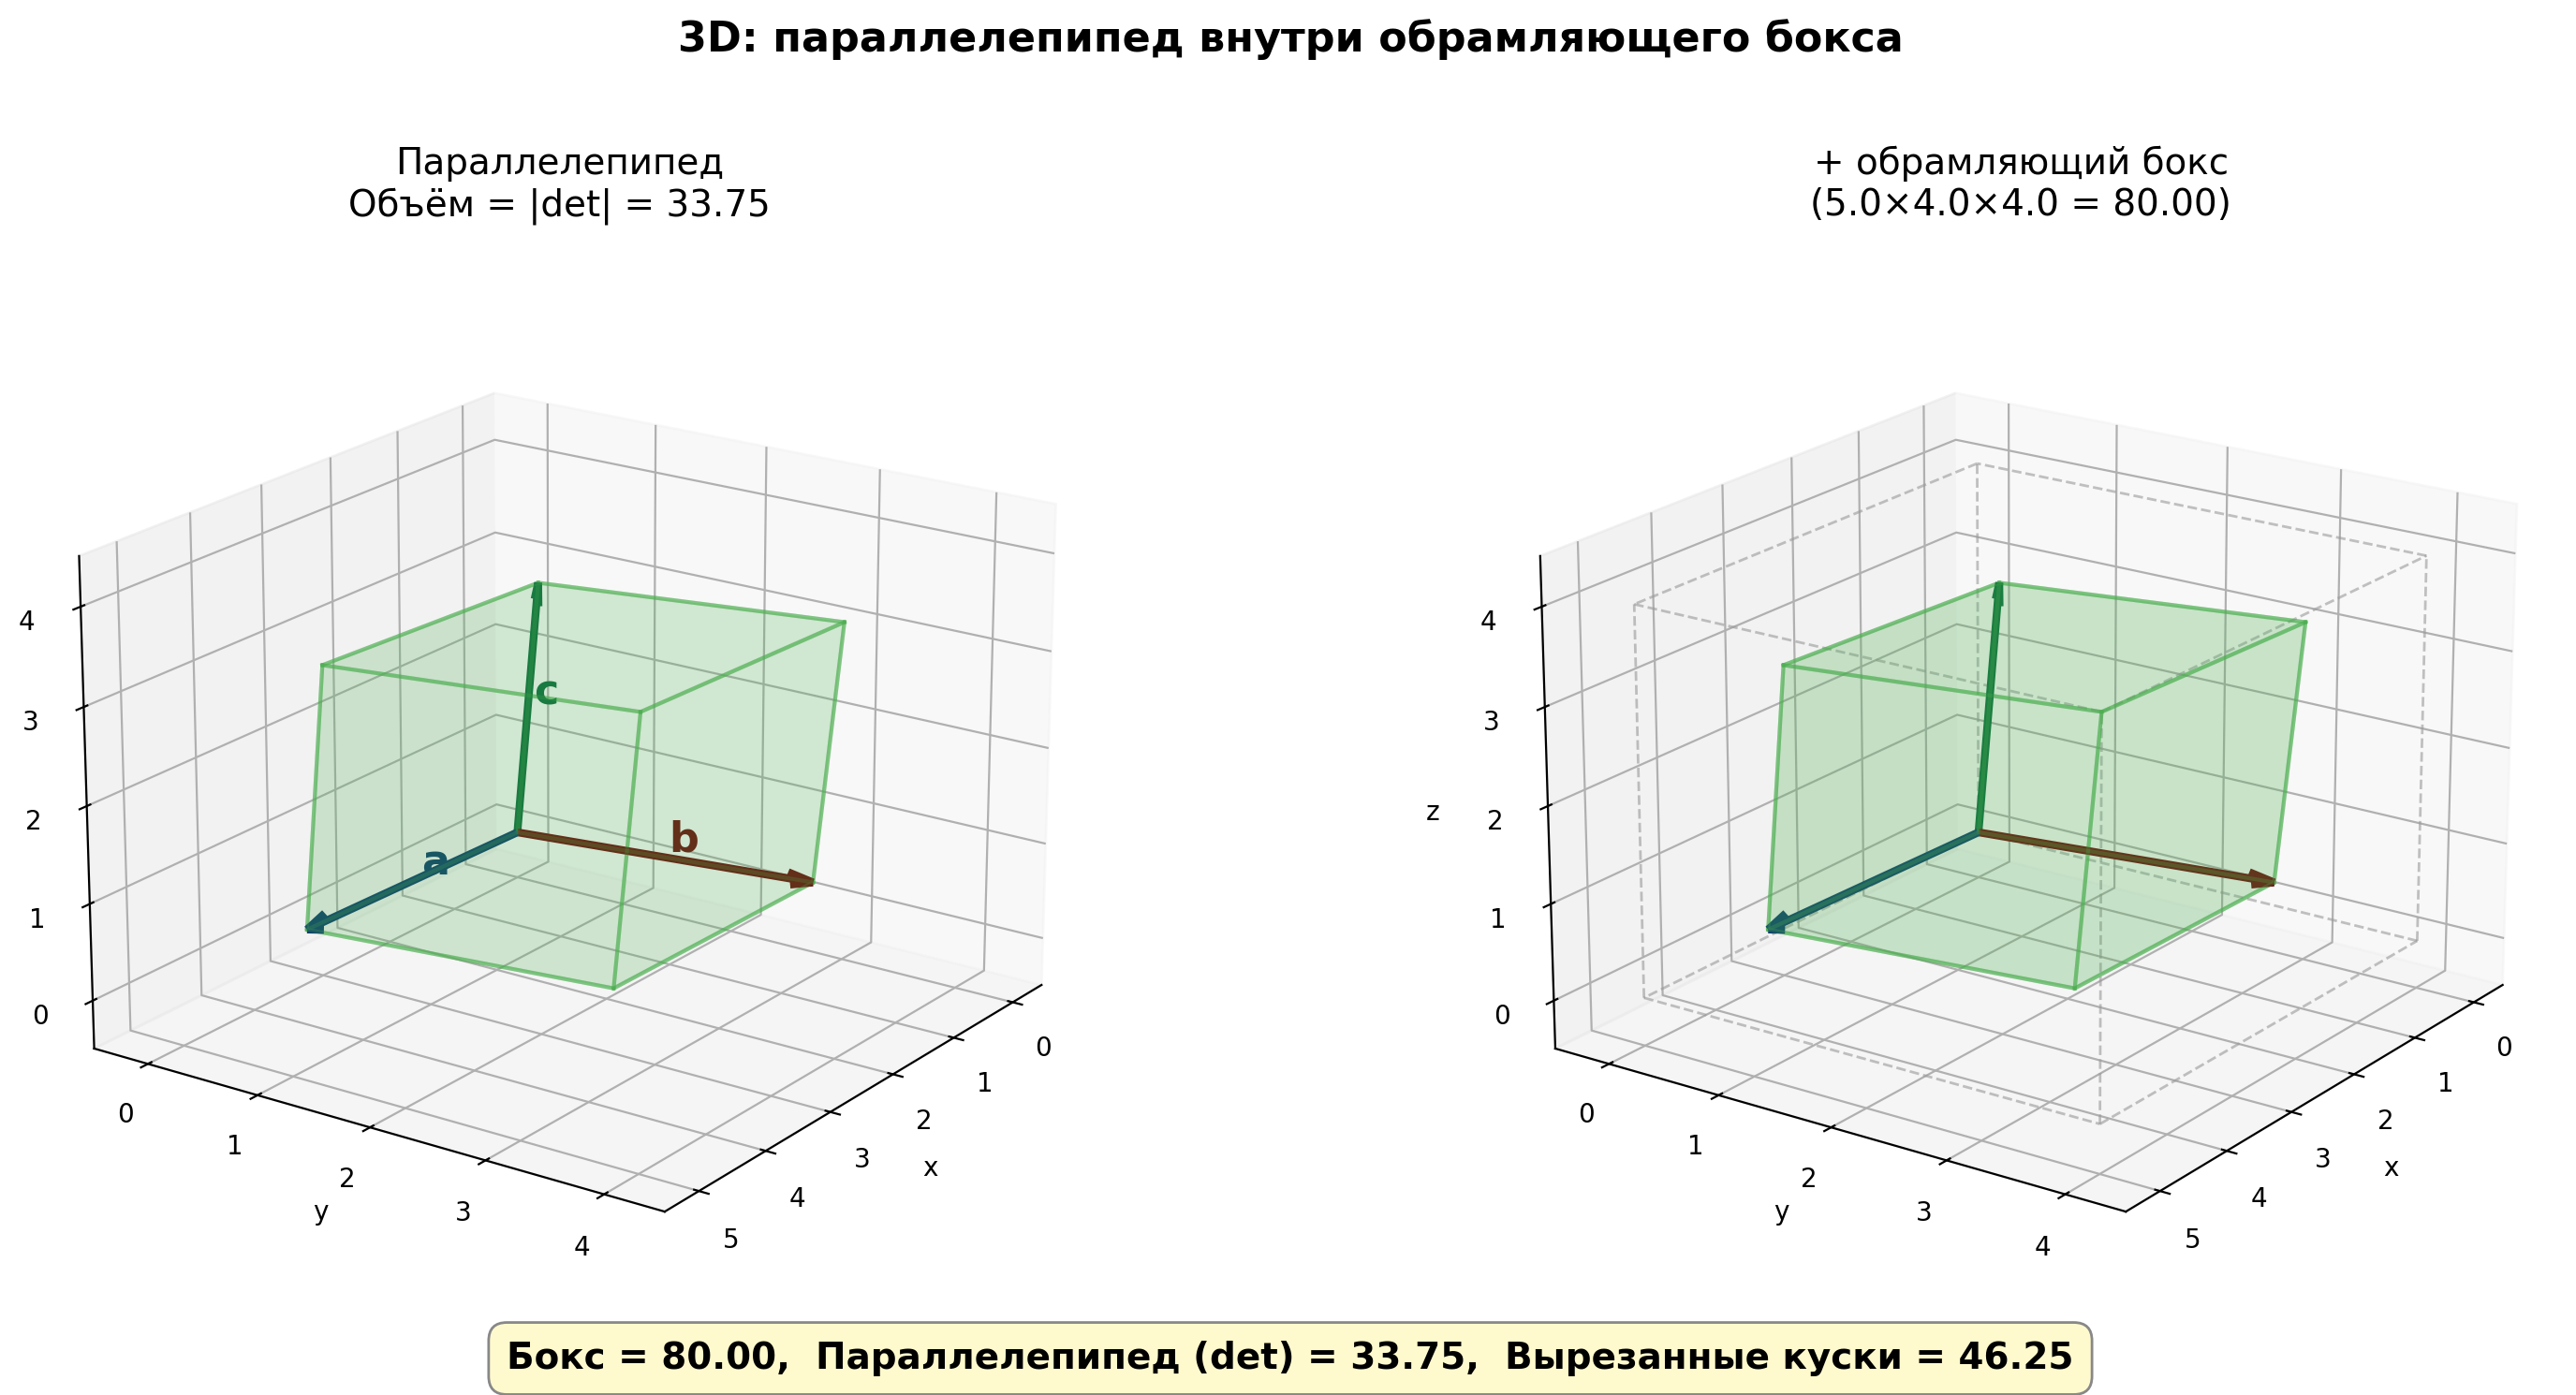

In [55]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_parallelepiped(ax, a, b, c, color='#4caf50', alpha=0.15, edge_alpha=0.6):
    """Draw parallelepiped spanned by vectors a, b, c from origin."""
    O = np.zeros(3)
    vertices = np.array([
        O, a, b, c,
        a+b, a+c, b+c,
        a+b+c
    ])

    faces = [
        [O, a, a+b, b],       # bottom
        [c, a+c, a+b+c, b+c], # top
        [O, a, a+c, c],       # front
        [b, a+b, a+b+c, b+c], # back
        [O, b, b+c, c],       # left
        [a, a+b, a+b+c, a+c], # right
    ]

    poly = Poly3DCollection(faces, alpha=alpha, facecolor=color,
                            edgecolor=color, linewidth=1.5)
    poly.set_alpha(alpha)
    ax.add_collection3d(poly)

    edges = [
        (O, a), (O, b), (O, c),
        (a, a+b), (a, a+c),
        (b, a+b), (b, b+c),
        (c, a+c), (c, b+c),
        (a+b, a+b+c), (a+c, a+b+c), (b+c, a+b+c),
    ]
    for p1, p2 in edges:
        ax.plot(*zip(p1, p2), color=color, alpha=edge_alpha, lw=1.5)


def draw_bounding_box(ax, a, b, c):
    """Draw axis-aligned bounding box."""
    s = a + b + c
    W, H, D = s
    corners = np.array([
        [0,0,0], [W,0,0], [W,H,0], [0,H,0],
        [0,0,D], [W,0,D], [W,H,D], [0,H,D],
    ])
    edges_idx = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7),
    ]
    for i, j in edges_idx:
        ax.plot(*zip(corners[i], corners[j]), '--', color='#999', lw=1, alpha=0.6)


a3d = np.array([4.0, 0.5, 0.5])
b3d = np.array([0.5, 3.0, 0.5])
c3d = np.array([0.5, 0.5, 3.0])

det_val = np.linalg.det(np.column_stack([a3d, b3d, c3d]))

fig = plt.figure(figsize=(16, 7))

# ─── Левая: параллелепипед ───
ax1 = fig.add_subplot(121, projection='3d')
draw_parallelepiped(ax1, a3d, b3d, c3d, color='#4caf50', alpha=0.12)

for v, name, col in [(a3d, 'a', '#0a3d6b'), (b3d, 'b', '#6b0a0a'), (c3d, 'c', '#0a6b3d')]:
    ax1.quiver(0, 0, 0, *v, color=col, arrow_length_ratio=0.08, lw=3)
    ax1.text(*(v/2 + 0.15), f'$\\mathbf{{{name}}}$', fontsize=16, color=col, fontweight='bold')

s = a3d + b3d + c3d
pad = 0.5
ax1.set_xlim([-pad, s[0]+pad])
ax1.set_ylim([-pad, s[1]+pad])
ax1.set_zlim([-pad, s[2]+pad])
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title(f'Параллелепипед\nОбъём = |det| = {abs(det_val):.2f}', fontsize=14, pad=15)
ax1.view_init(elev=20, azim=35)

# ─── Правая: параллелепипед + бокс ───
ax2 = fig.add_subplot(122, projection='3d')
draw_bounding_box(ax2, a3d, b3d, c3d)
draw_parallelepiped(ax2, a3d, b3d, c3d, color='#4caf50', alpha=0.15)

for v, name, col in [(a3d, 'a', '#0a3d6b'), (b3d, 'b', '#6b0a0a'), (c3d, 'c', '#0a6b3d')]:
    ax2.quiver(0, 0, 0, *v, color=col, arrow_length_ratio=0.08, lw=3)

box_vol = s[0] * s[1] * s[2]
ax2.set_xlim([-pad, s[0]+pad])
ax2.set_ylim([-pad, s[1]+pad])
ax2.set_zlim([-pad, s[2]+pad])
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_title(f'+ обрамляющий бокс\n({s[0]:.1f}×{s[1]:.1f}×{s[2]:.1f} = {box_vol:.2f})',
              fontsize=14, pad=15)
ax2.view_init(elev=20, azim=35)

fig.text(0.5, -0.01,
    f'Бокс = {box_vol:.2f},  Параллелепипед (det) = {det_val:.2f},  '
    f'Вырезанные куски = {box_vol - det_val:.2f}',
    ha='center', fontsize=14, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fffacd', edgecolor='#888'))

plt.suptitle('3D: параллелепипед внутри обрамляющего бокса', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

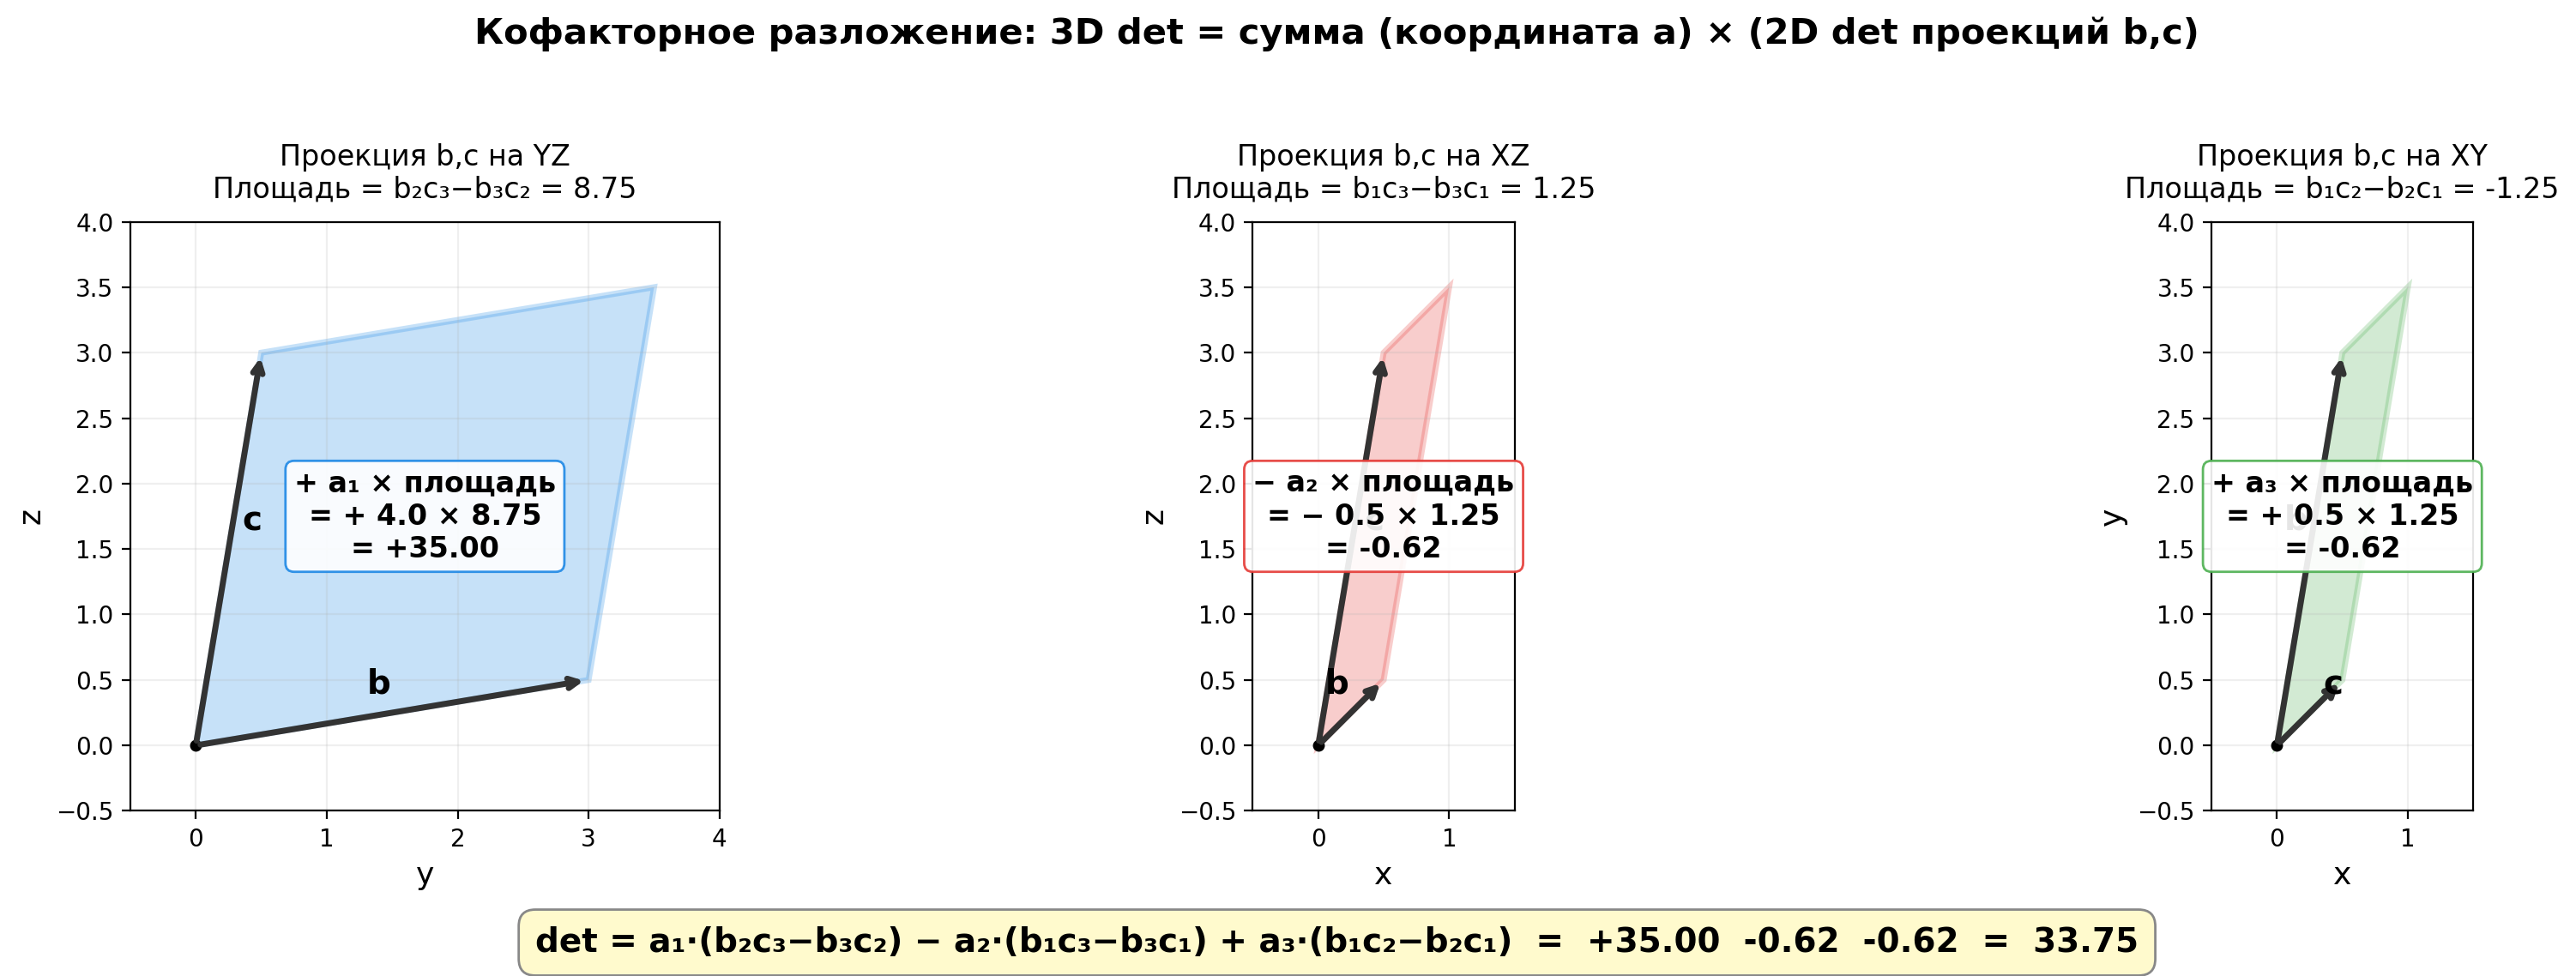

In [56]:
a_v = a3d
b_v = b3d
c_v = c3d
a1, a2, a3 = a_v
b1, b2, b3_ = b_v
c1, c2, c3_ = c_v

cofactor_1 = b2*c3_ - b3_*c2   # M₁₁: площадь проекции b,c на yz
cofactor_2 = b1*c3_ - b3_*c1   # M₁₂: площадь проекции b,c на xz
cofactor_3 = b1*c2  - b2*c1    # M₁₃: площадь проекции b,c на xy

det_check = a1*cofactor_1 - a2*cofactor_2 + a3*cofactor_3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    f'Проекция b,c на YZ\nПлощадь = b₂c₃−b₃c₂ = {cofactor_1:.2f}',
    f'Проекция b,c на XZ\nПлощадь = b₁c₃−b₃c₁ = {cofactor_2:.2f}',
    f'Проекция b,c на XY\nПлощадь = b₁c₂−b₂c₁ = {cofactor_3:.2f}',
]

proj_b = [np.array([b2, b3_]), np.array([b1, b3_]), np.array([b1, b2])]
proj_c = [np.array([c2, c3_]), np.array([c1, c3_]), np.array([c1, c2])]
a_coords = [a1, a2, a3]
signs = ['+', '−', '+']
axis_labels = [('y', 'z'), ('x', 'z'), ('x', 'y')]
colors = ['#1e88e5', '#e53935', '#4caf50']
cofactors = [cofactor_1, -cofactor_2, cofactor_3]

for i, ax in enumerate(axes):
    pb, pc = proj_b[i], proj_c[i]
    O2 = np.array([0, 0])
    verts = np.array([O2, pb, pb+pc, pc])

    ax.add_patch(Polygon(verts, closed=True, facecolor=colors[i], alpha=0.25,
                         edgecolor=colors[i], linewidth=2.5))
    ax.annotate('', xy=pb, xytext=O2, arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))
    ax.annotate('', xy=pc, xytext=O2, arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))

    ax.text(pb[0]/2-0.2, pb[1]/2+0.15, r'$\mathbf{b}$', fontsize=14, fontweight='bold')
    ax.text(pc[0]/2+0.1, pc[1]/2+0.15, r'$\mathbf{c}$', fontsize=14, fontweight='bold')

    cx, cy = verts.mean(axis=0)
    ax.text(cx, cy, f'{signs[i]} a{chr(0x2081+i)} × площадь\n= {signs[i]} {a_coords[i]:.1f} × {abs(cofactors[i]):.2f}\n= {a_coords[i]*cofactors[i]:+.2f}',
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=colors[i]))

    ax.plot(0, 0, 'ko', ms=4)
    all_pts = verts
    pad = 0.5
    ax.set_xlim(all_pts[:,0].min()-pad, all_pts[:,0].max()+pad)
    ax.set_ylim(all_pts[:,1].min()-pad, all_pts[:,1].max()+pad)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlabel(axis_labels[i][0], fontsize=13)
    ax.set_ylabel(axis_labels[i][1], fontsize=13)
    ax.set_title(titles[i], fontsize=12, pad=10)

fig.text(0.5, -0.04,
    f'det = a₁·(b₂c₃−b₃c₂) − a₂·(b₁c₃−b₃c₁) + a₃·(b₁c₂−b₂c₁)'
    f'  =  {a1*cofactor_1:+.2f}  {a2*(-cofactor_2):+.2f}  {a3*cofactor_3:+.2f}'
    f'  =  {det_check:.2f}',
    ha='center', fontsize=14, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fffacd', edgecolor='#888'))

plt.suptitle('Кофакторное разложение: 3D det = сумма (координата a) × (2D det проекций b,c)',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Как читать 3D-картинки

**Параллелепипед + бокс:**  
Та же идея, что в 2D — обводим параллелепипед осевым боксом, вырезаем куски, получаем det.
Но кусков намного больше, рисовать их все — каша.

**Кофакторное разложение (три картинки):**  
Вместо этого 3D-определитель **раскладывается** в сумму трёх 2D-определителей:
- Проецируем b и c на каждую координатную плоскость (YZ, XZ, XY)
- Считаем площадь каждой проекции (это 2D det, который мы уже умеем)
- Умножаем на соответствующую координату вектора **a**
- Складываем со знаками +, −, +

Это и есть **разложение по строке** (cofactor expansion) — оно сводит 3D-задачу к трём 2D-задачам, которые мы уже разобрали выше.

## Итого

**det(a, b) = a₁b₂ − a₂b₁** — это ориентированная площадь параллелограмма, натянутого на a и b:  
- Модуль |det| = площадь  
- Знак = ориентация (направление обхода от a к b)